# Exploratory Data Analysis (EDA) on Sales Dataset

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Sales Dataset to identify sales trends, customer purchasing behaviour, and business insights using Python libraries.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

In [2]:
df = pd.read_excel("../dataset/sales_dataset.xlsx")

df.head()

,index,Order ID,Cust ID,Gender,Age,Date,Status,Channel,SKU,Category,Size,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,1,171-1029312-3038738,1029312,Women,44,2022-12-04,Delivered,Myntra,JNE1233-BLUE-KR-031-XXL,kurta,XXL,1,INR,376,MOHALI,PUNJAB,140301,IN,False
1,2,405-2183842-2225946,2183842,Women,29,2022-12-04,Delivered,Ajio,SET414-KR-NP-L,Set,L,1,INR,1449,GURUGRAM,HARYANA,122002,IN,False
2,3,171-1641533-8921966,1641533,Women,67,2022-12-04,Delivered,Myntra,SET261-KR-PP-S,Set,S,1,INR,453,KOLKATA,WEST BENGAL,700029,IN,False
3,4,404-7490807-6300351,7490807,Women,20,2022-12-04,Delivered,Amazon,SET110-KR-PP-M,Set,M,1,INR,729,THANJAVUR,TAMIL NADU,613007,IN,False
4,5,403-9293516-4577154,9293516,Women,62,2022-12-04,Delivered,Myntra,JNE2294-KR-A-XXL,kurta,XXL,1,INR,544,GURUGRAM,HARYANA,122001,IN,False


# Dataset Overview

Understanding the dataset before beginning the analysis.

In [4]:
print(df.shape)

(31047, 19)


### The dataset contains 31047 rows and 19 columns

In [5]:
df.columns

Index(['index', 'Order ID', 'Cust ID', 'Gender', 'Age', 'Date', 'Status',
       'Channel ', 'SKU', 'Category', 'Size', 'Qty', 'currency', 'Amount',
       'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'B2B'],
      dtype='object')

### The dataset contains following columns:
- index
- Order ID
- Cust ID
- Gender
- Age
- Date
- Status
- Channel
- SKU
- Category
- Size
- Qty
- currency
- Amount
- ship-city
- ship-state
- ship-postal-code
- ship-country
- B2B

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31047 entries, 0 to 31046
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             31047 non-null  int64         
 1   Order ID          31047 non-null  object        
 2   Cust ID           31047 non-null  int64         
 3   Gender            31047 non-null  object        
 4   Age               31047 non-null  int64         
 5   Date              31047 non-null  datetime64[ns]
 6   Status            31047 non-null  object        
 7   Channel           31047 non-null  object        
 8   SKU               31047 non-null  object        
 9   Category          31047 non-null  object        
 10  Size              31047 non-null  object        
 11  Qty               31047 non-null  object        
 12  currency          31047 non-null  object        
 13  Amount            31047 non-null  int64         
 14  ship-city         3104

In [7]:
df.isnull().sum()

index               0
Order ID            0
Cust ID             0
Gender              0
Age                 0
Date                0
Status              0
Channel             0
SKU                 0
Category            0
Size                0
Qty                 0
currency            0
Amount              0
ship-city           0
ship-state          0
ship-postal-code    0
ship-country        0
B2B                 0
dtype: int64

#### Insight: The output shows that there are no missing (null) values in any of the columns of the dataset.

In [8]:
df.duplicated().sum()

np.int64(0)

#### Insight: The output shows that there are no duplicate values in any of the columns of the dataset.

In [9]:
df[['Age', 'Amount']].describe()

,Age,Amount
count,31047.000000,31047.000000
mean,39.496570,682.074822
std,15.117233,268.582173
min,18.000000,229.000000
25%,28.000000,486.000000
50%,37.000000,646.000000
75%,47.000000,794.000000
max,78.000000,3036.000000


In [10]:
df[['Gender','Channel ','Category','ship-state']].describe(include='object')

,Gender,Channel,Category,ship-state
count,31047,31047,31047,31047
unique,4,7,8,50
top,Women,Amazon,Set,MAHARASHTRA
freq,21479,11016,12391,4519


#### Insight:

This provides summary statistics for categorical columns such as:

- Gender
- Category
- Channel
- State

## Now, create additional columns required for sales trend analysis and customer segmentation.

In [11]:
df['Date'].head()

0   2022-12-04
1   2022-12-04
2   2022-12-04
3   2022-12-04
4   2022-12-04
Name: Date, dtype: datetime64[ns]

In [12]:
df['Date'].dtype

dtype('<M8[ns]')

In [13]:
df['month'] = df['Date'].dt.month_name()

In [14]:
df['quarter'] = df['Date'].dt.quarter

In [15]:
df['year'] = df['Date'].dt.year

In [16]:
df['week_day'] = df['Date'].dt.day_name()

In [17]:
df.rename(columns = {'Amount': 'Revenue'},inplace = True)

In [18]:
df.Revenue.head()

0     376
1    1449
2     453
3     729
4     544
Name: Revenue, dtype: int64

In [19]:
# Standardize the values in the **Gender** column by replacing different representations of the same gender with a consistent format.
df['Gender'] = df['Gender'].replace({
    'M': 'Men',
    'm': 'Men',
    'Man': 'Men',
    'W': 'Women',
    'w': 'Women',
    'Woman': 'Women'
})

### Customer age group

In [21]:
bins = [0,18,25,35,45,55,100]

labels = [
    '0-18',
    '19-25',
    '26-35',
    '36-45',
    '46-55',
    '55+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [22]:
df[['Age Group']].head()

,Age Group
0,36-45
1,26-35
2,55+
3,19-25
4,55+


In [23]:
df.head()

,index,Order ID,Cust ID,Gender,Age,Date,Status,Channel,SKU,Category,...,ship-city,ship-state,ship-postal-code,ship-country,B2B,month,quarter,year,week_day,Age Group
0,1,171-1029312-3038738,1029312,Women,44,2022-12-04,Delivered,Myntra,JNE1233-BLUE-KR-031-XXL,kurta,...,MOHALI,PUNJAB,140301,IN,False,December,4,2022,Sunday,36-45
1,2,405-2183842-2225946,2183842,Women,29,2022-12-04,Delivered,Ajio,SET414-KR-NP-L,Set,...,GURUGRAM,HARYANA,122002,IN,False,December,4,2022,Sunday,26-35
2,3,171-1641533-8921966,1641533,Women,67,2022-12-04,Delivered,Myntra,SET261-KR-PP-S,Set,...,KOLKATA,WEST BENGAL,700029,IN,False,December,4,2022,Sunday,55+
3,4,404-7490807-6300351,7490807,Women,20,2022-12-04,Delivered,Amazon,SET110-KR-PP-M,Set,...,THANJAVUR,TAMIL NADU,613007,IN,False,December,4,2022,Sunday,19-25
4,5,403-9293516-4577154,9293516,Women,62,2022-12-04,Delivered,Myntra,JNE2294-KR-A-XXL,kurta,...,GURUGRAM,HARYANA,122001,IN,False,December,4,2022,Sunday,55+


In [24]:
df['Status'].value_counts()

Status
Delivered    28641
Returned      1045
Cancelled      844
Refunded       517
Name: count, dtype: int64

In [25]:
df.columns = df.columns.str.strip()

In [26]:
df['Channel'].value_counts()

Channel
Amazon      11016
Myntra       7254
Flipkart     6703
Ajio         1931
Nalli        1484
Meesho       1398
Others       1261
Name: count, dtype: int64

#### Insight:
This column provides the platform where the purchase is done.
For example: Amazon, Myntra, Flipkart, Ajio, Nalli, Meesho and many more...    

In [27]:
df.head()

,index,Order ID,Cust ID,Gender,Age,Date,Status,Channel,SKU,Category,...,ship-city,ship-state,ship-postal-code,ship-country,B2B,month,quarter,year,week_day,Age Group
0,1,171-1029312-3038738,1029312,Women,44,2022-12-04,Delivered,Myntra,JNE1233-BLUE-KR-031-XXL,kurta,...,MOHALI,PUNJAB,140301,IN,False,December,4,2022,Sunday,36-45
1,2,405-2183842-2225946,2183842,Women,29,2022-12-04,Delivered,Ajio,SET414-KR-NP-L,Set,...,GURUGRAM,HARYANA,122002,IN,False,December,4,2022,Sunday,26-35
2,3,171-1641533-8921966,1641533,Women,67,2022-12-04,Delivered,Myntra,SET261-KR-PP-S,Set,...,KOLKATA,WEST BENGAL,700029,IN,False,December,4,2022,Sunday,55+
3,4,404-7490807-6300351,7490807,Women,20,2022-12-04,Delivered,Amazon,SET110-KR-PP-M,Set,...,THANJAVUR,TAMIL NADU,613007,IN,False,December,4,2022,Sunday,19-25
4,5,403-9293516-4577154,9293516,Women,62,2022-12-04,Delivered,Myntra,JNE2294-KR-A-XXL,kurta,...,GURUGRAM,HARYANA,122001,IN,False,December,4,2022,Sunday,55+


#### Newly created columns:
Newly created columns are : month, quarter, year, week_days, Age Group 

### Monthly Sales Trend 

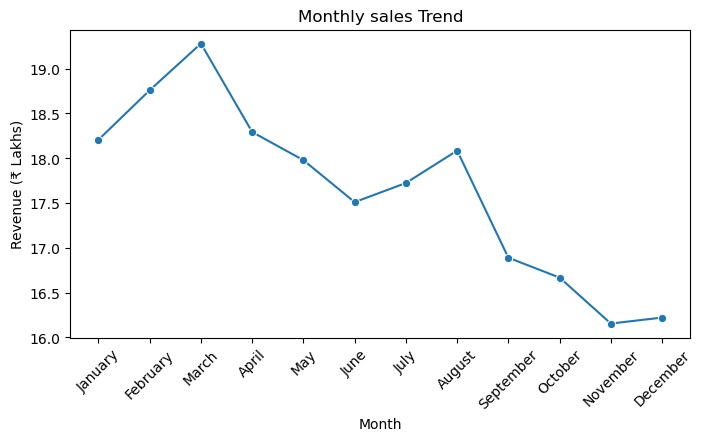

In [91]:
monthly_sales = df.groupby('month')['Revenue'].sum()
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales = monthly_sales / 100000
plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_sales.index,y = monthly_sales.values, marker = 'o')
plt.title('Monthly sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹ Lakhs)')
plt.xticks(rotation=45)
plt.show()


#### Insight:
Sales increased steadily from January and reached their peak in March. After March, revenue gradually declined, with a slight recovery in August before falling to its lowest level in November. This indicates seasonal variations in customer demand and suggests that the business should prepare inventory and marketing campaigns before peak months.

### Quarterly Sales Trend

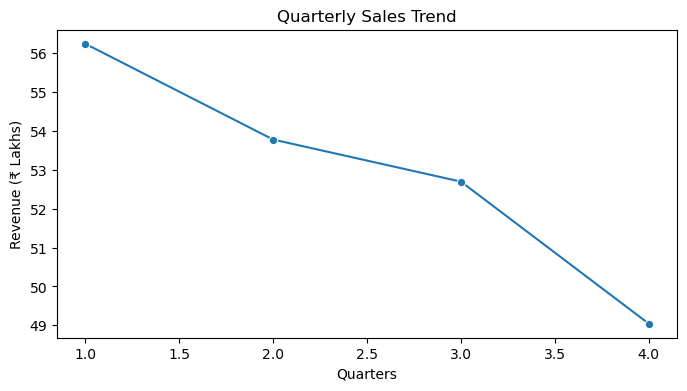

In [92]:
quarterly_sales = df.groupby("quarter")['Revenue'].sum()
quarterly_sales = quarterly_sales/100000
plt.figure(figsize = (8,4))
sns.lineplot(x=quarterly_sales.index, y=quarterly_sales.values, marker = 'o')
plt.title("Quarterly Sales Trend")
plt.xlabel('Quarters')
plt.ylabel('Revenue (₹ Lakhs)')
plt.show()

#### Insight: 
The first quarter generated the highest revenue, while sales declined in the following quarters. This trend suggests stronger customer demand during the beginning of the year and highlights the need for promotional strategies in later quarters.

### Customer Age Group Distribution

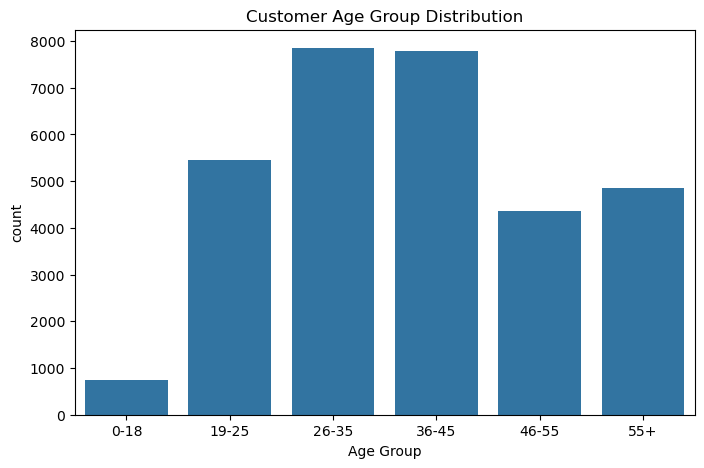

In [122]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Age Group',
    order=['0-18','19-25','26-35','36-45','46-55','55+']
)

plt.title("Customer Age Group Distribution")
plt.show()

#### Insight:
Customers aged 26–35 years represent the largest customer segment, followed by those aged 36–45 years. This indicates that young and middle-aged adults form the primary customer base and should be the focus of marketing campaigns.

### Gender Distribution

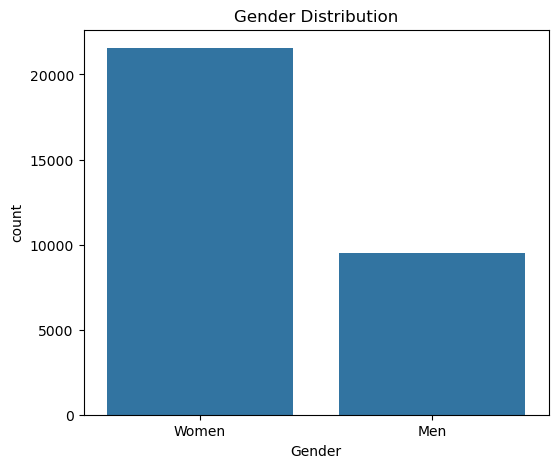

In [94]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x='Gender')

plt.title("Gender Distribution")

plt.show()

#### Insight:
Female customers account for a significantly larger share of orders compared to male customers. This suggests that the store's products are more popular among women, making them an important target audience for promotional activities.

### Top 10 Best Selling Products

In [112]:
df['Qty'] = df['Qty'].replace({"One" : 1,
                              "Two" : 2})

df['Qty']=pd.to_numeric(df['Qty'])

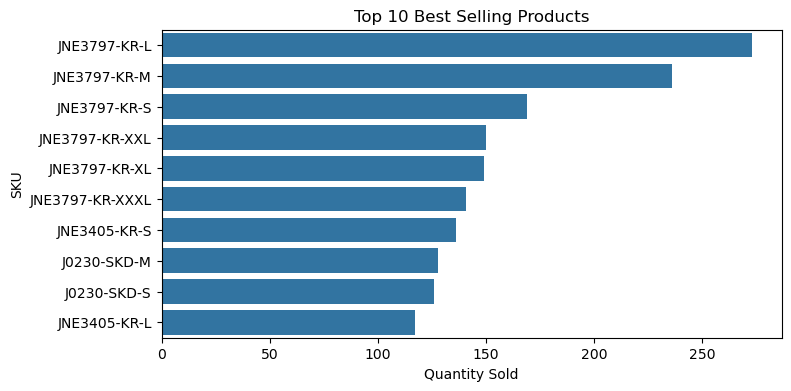

In [123]:
top_products = ( df.groupby('SKU')['Qty'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(8,4))
sns.barplot( x=top_products.values,y=top_products.index)
plt.title("Top 10 Best Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("SKU")
plt.show()

#### Insight:
The chart identifies the top 10 best-selling products based on quantity sold. These products contribute substantially to total sales and should be prioritized for inventory management and promotional campaigns.

### Revenue by Product Category

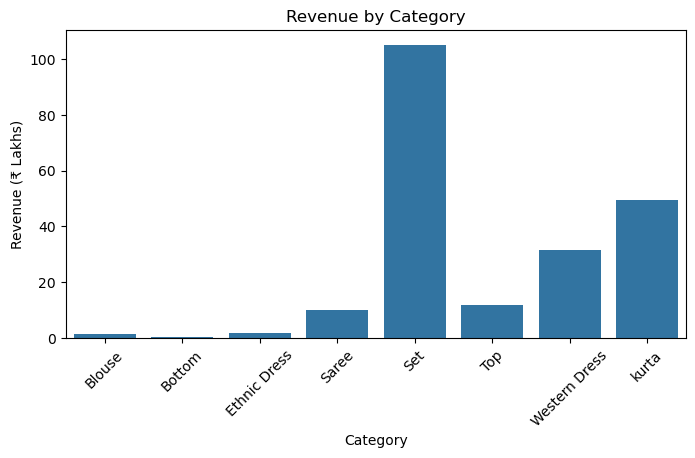

In [126]:
category_sales = df.groupby('Category')['Revenue'].sum()
category_sales = category_sales/100000
plt.figure(figsize = (8,4))

sns.barplot(x=category_sales.index,y=category_sales.values)
plt.xticks(rotation = 45)
plt.ylabel('Revenue (₹ Lakhs)')
plt.title("Revenue by Category")
plt.show()

#### Insight:
The Set category generates the highest revenue among all product categories, indicating strong customer demand. Increasing inventory and marketing efforts for this category could further improve overall sales.

### Correlation Heatmap

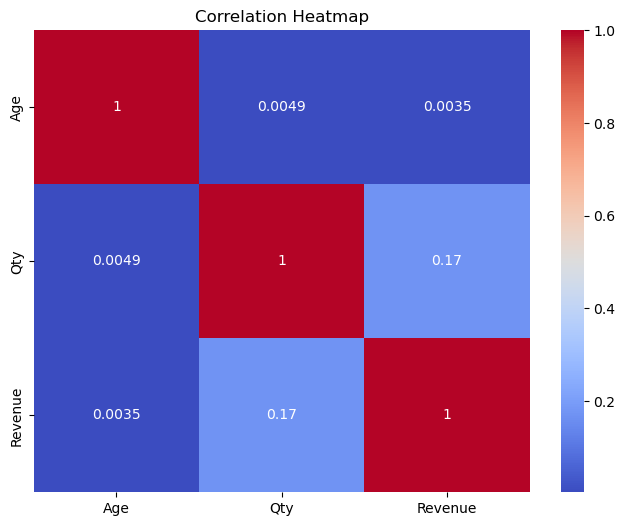

In [133]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Age','Qty','Revenue']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

#### Insights :
The heatmap indicates that customer age has almost no relationship with the quantity purchased or the revenue generated. A weak positive correlation exists between quantity and revenue, suggesting that purchasing more items generally leads to slightly higher revenue. Overall, the numerical variables show only weak correlations.

### Revenue by different Channels

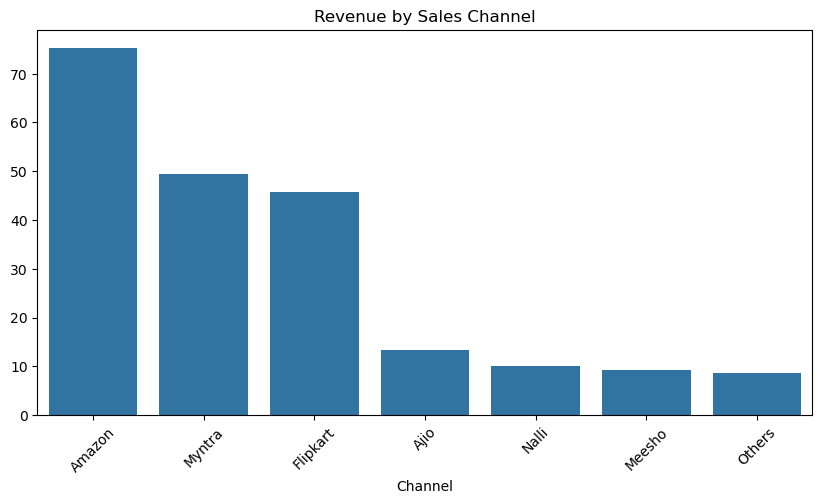

In [28]:
channel_sales = (
    df.groupby('Channel')['Revenue']
      .sum()
      .sort_values(ascending=False)
)
channel_sales =channel_sales/100000
plt.figure(figsize=(10,5))

sns.barplot(
    x=channel_sales.index,
    y=channel_sales.values
)

plt.xticks(rotation=45)

plt.title("Revenue by Sales Channel")

plt.show()

#### Insights : 
Amazon is the highest revenue-generating sales channel, indicating that it is the most effective platform for reaching customers. The business should continue investing in this channel while improving the performance of other platforms.

### Sales by States

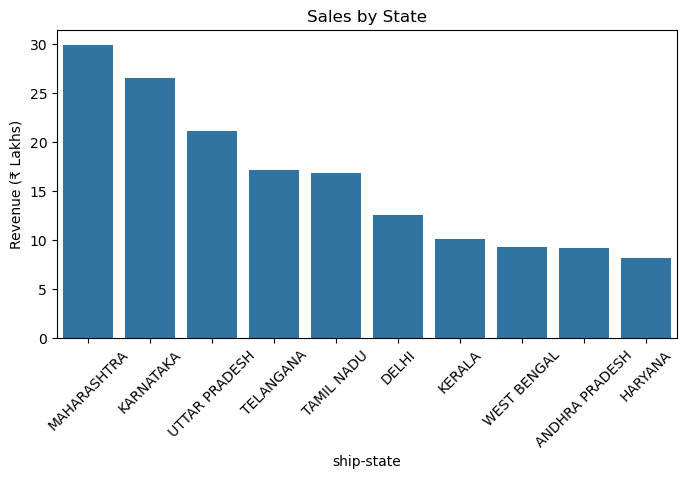

In [29]:
state_sales = df.groupby('ship-state')['Revenue'].sum().sort_values(ascending = False).head(10)
state_sales = state_sales/100000
plt.figure(figsize=(8,4))
sns.barplot(x=state_sales.index,y=state_sales.values)
plt.xticks(rotation=45)
plt.ylabel("Revenue (₹ Lakhs)")
plt.title("Sales by State")
plt.show()

#### Insight:
The analysis highlights the top 10 revenue-generating states. These regions represent the strongest markets for the business and should be prioritized for future expansion and targeted marketing campaigns.

### Order Status Distribution

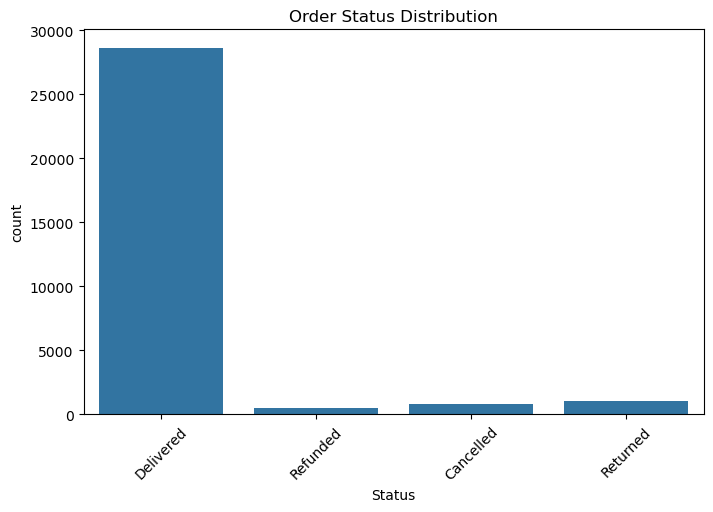

In [132]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Status'
)

plt.xticks(rotation=45)

plt.title("Order Status Distribution")

plt.show()

#### Insights : 
Most orders were successfully delivered, while a smaller proportion were cancelled or returned. Reducing cancellations and returns can improve customer satisfaction and increase overall profitability.

### Business Insights

1. Sales were highest in the first quarter of the year.

2. Customers aged 26–35 are the main buyers.

3. Female customers placed more orders than male customers.

4. The Set category generated the highest revenue.

5. Amazon is the highest revenue-generating sales channel.

6. A few states contribute a large share of total revenue.

### Business Recommendations

1. Increase stock before the peak sales months.

2. Focus marketing on customers aged 26–35.

3. Continue promoting products on Amazon.

4. Increase the availability of products in the Set category.

5. Improve sales in low-performing states through marketing campaigns.

### Conclusion

This project analyzed the Vrinda Store sales data using Python. The analysis helped identify sales trends, customer preferences, product performance, and revenue distribution. The findings can help the business make better decisions related to marketing, inventory, and sales planning.